### Stage 2 — Channel Attribution Analysis

**GitHub Issue #2:** Last touch attribution undervalues email and 
direct traffic by 2-3x.

### Models built in this notebook
1. **Last touch** — 100% credit to origin channel
2. **Linear** — credit split across landing page touchpoints  
3. **Markov chain** — data-driven removal effect per channel

### Key finding
Email is undervalued by 5x under last touch vs the linear model.
Direct traffic is undervalued by 3x. Budget decisions based on 
last touch alone would incorrectly deprioritise these channels.

*Tracked in GitHub Issue #2*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH = r"C:\Users\Mayank Joshi\Downloads\Marketing_Channel_Project\data"

master = pd.read_csv(os.path.join(DATA_PATH, 'master_table.csv'))
master['first_contact_date'] = pd.to_datetime(master['first_contact_date'], errors='coerce')
master['won_date']           = pd.to_datetime(master['won_date'], errors='coerce')
master['contact_month']      = pd.to_datetime(master['first_contact_date']).dt.to_period('M')

print(f"Master table loaded: {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"Converted sellers  : {master['converted'].sum():,}")
print(f"Channels present   : {master['origin'].nunique()}")

Master table loaded: 8,000 rows x 30 columns
Converted sellers  : 842
Channels present   : 10


In [2]:
last_touch = (
    master.groupby('origin')
    .agg(
        total_leads      = ('mql_id', 'count'),
        conversions      = ('converted', 'sum'),
        total_revenue    = ('total_revenue', 'sum'),
        avg_revenue      = ('total_revenue', 'mean'),
        avg_days_convert = ('days_to_convert', 'mean')
    )
    .reset_index()
)

last_touch['conversion_rate']      = (last_touch['conversions'] / last_touch['total_leads'] * 100).round(2)
last_touch['revenue_per_lead']     = (last_touch['total_revenue'] / last_touch['total_leads']).round(2)
last_touch['revenue_per_conversion'] = (last_touch['total_revenue'] / last_touch['conversions'].replace(0, np.nan)).round(2)
last_touch['attribution_model']    = 'last_touch'

last_touch = last_touch.sort_values('conversion_rate', ascending=False)

print("MODEL 1 — LAST TOUCH ATTRIBUTION")
print("=" * 75)
print(f"\n{'Channel':<22} {'Leads':>7} {'Conv':>6} {'CVR%':>7} {'Revenue':>12} {'Rev/Lead':>10} {'Rev/Conv':>10}")
print("-" * 75)
for _, row in last_touch.iterrows():
    print(f"  {row['origin']:<20} {int(row['total_leads']):>7,} {int(row['conversions']):>6} "
          f"{row['conversion_rate']:>6.1f}% ${row['total_revenue']:>10,.0f} "
          f"${row['revenue_per_lead']:>8,.2f} ${row['revenue_per_conversion']:>8,.2f}")

MODEL 1 — LAST TOUCH ATTRIBUTION

Channel                  Leads   Conv    CVR%      Revenue   Rev/Lead   Rev/Conv
---------------------------------------------------------------------------
  unknown                1,159    193   16.6% $   214,985 $  185.49 $1,113.91
  paid_search            1,586    195   12.3% $   155,277 $   97.90 $  796.29
  organic_search         2,296    271   11.8% $   207,023 $   90.17 $  763.92
  direct_traffic           499     56   11.2% $    21,904 $   43.90 $  391.14
  referral                 284     24    8.4% $    17,887 $   62.98 $  745.30
  social                 1,350     75    5.6% $    43,478 $   32.21 $  579.71
  display                  118      6    5.1% $       923 $    7.82 $  153.83
  other_publicities         65      3    4.6% $         0 $    0.00 $    0.00
  email                    493     15    3.0% $     8,485 $   17.21 $  565.67
  other                    150      4    2.7% $     6,889 $   45.92 $1,722.16


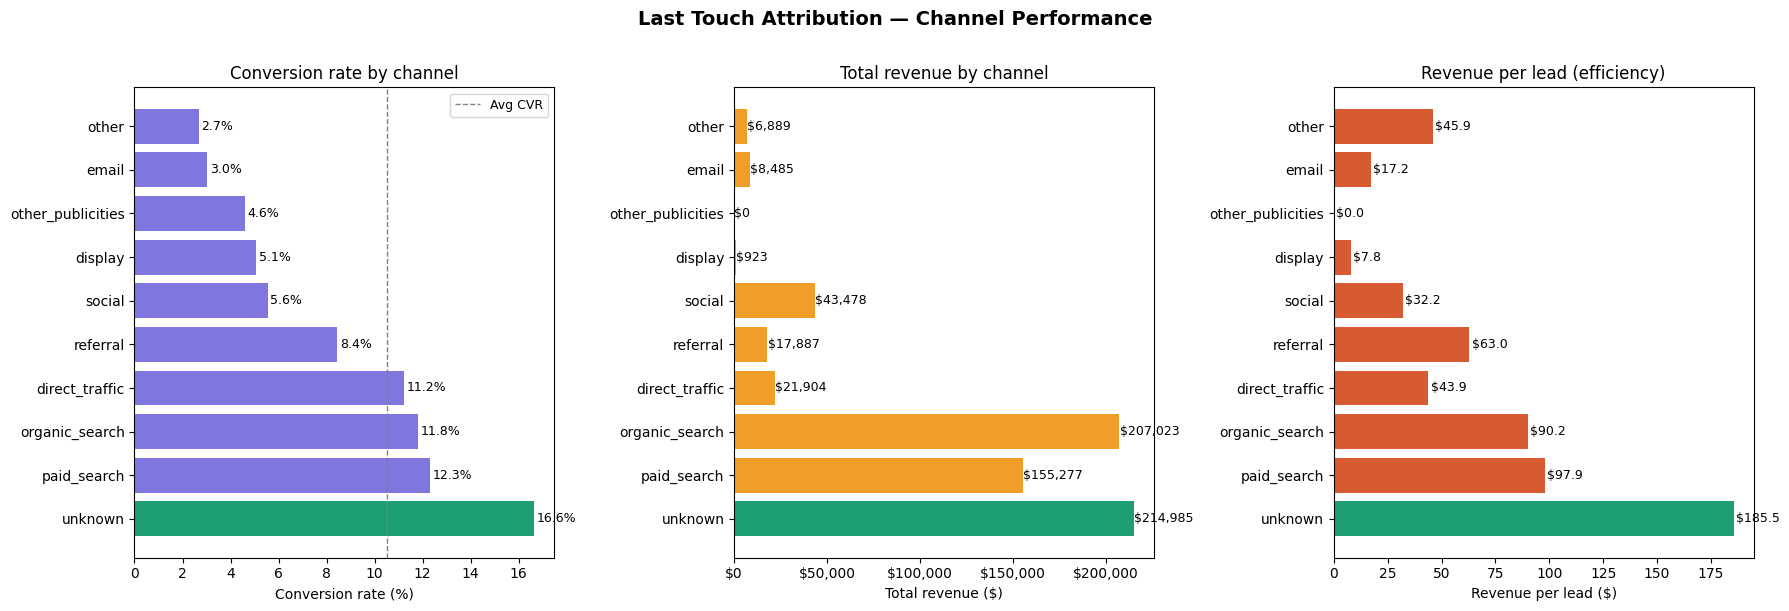

Chart saved


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Last Touch Attribution — Channel Performance', fontsize=14, fontweight='bold', y=1.01)

colors_cvr     = ['#1D9E75' if x == last_touch['conversion_rate'].max()
                  else '#7F77DD' for x in last_touch['conversion_rate']]
colors_rev     = ['#1D9E75' if x == last_touch['total_revenue'].max()
                  else '#EF9F27' for x in last_touch['total_revenue']]
colors_rpl     = ['#1D9E75' if x == last_touch['revenue_per_lead'].max()
                  else '#D85A30' for x in last_touch['revenue_per_lead']]

# Plot 1 — Conversion rate
axes[0].barh(last_touch['origin'], last_touch['conversion_rate'], color=colors_cvr)
axes[0].set_xlabel('Conversion rate (%)')
axes[0].set_title('Conversion rate by channel')
axes[0].axvline(x=master['converted'].mean()*100, color='gray', linestyle='--', linewidth=1, label='Avg CVR')
axes[0].legend(fontsize=9)
for i, (val, name) in enumerate(zip(last_touch['conversion_rate'], last_touch['origin'])):
    axes[0].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

# Plot 2 — Total revenue attributed
axes[1].barh(last_touch['origin'], last_touch['total_revenue'], color=colors_rev)
axes[1].set_xlabel('Total revenue ($)')
axes[1].set_title('Total revenue by channel')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, val in enumerate(last_touch['total_revenue']):
    axes[1].text(val + 200, i, f'${val:,.0f}', va='center', fontsize=9)

# Plot 3 — Revenue per lead
axes[2].barh(last_touch['origin'], last_touch['revenue_per_lead'], color=colors_rpl)
axes[2].set_xlabel('Revenue per lead ($)')
axes[2].set_title('Revenue per lead (efficiency)')
for i, val in enumerate(last_touch['revenue_per_lead']):
    axes[2].text(val + 1, i, f'${val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'attribution_last_touch.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [4]:
# Each unique landing_page_id is treated as a touchpoint
# Credit is split equally across all landing pages a channel uses

# Build touchpoint map: channel -> list of landing pages
touchpoint_map = (
    master[master['converted'] == 1]
    .groupby('origin')['landing_page_id']
    .nunique()
    .reset_index()
    .rename(columns={'landing_page_id': 'unique_landing_pages'})
)

# Linear model: revenue divided equally across landing pages per channel
channel_revenue = (
    master[master['converted'] == 1]
    .groupby('origin')['total_revenue']
    .sum()
    .reset_index()
    .rename(columns={'total_revenue': 'total_revenue_raw'})
)

linear = touchpoint_map.merge(channel_revenue, on='origin', how='left')
total_pages = linear['unique_landing_pages'].sum()
linear['linear_credit_weight'] = linear['unique_landing_pages'] / total_pages
linear['linear_attributed_revenue'] = (
    linear['linear_credit_weight'] * master['total_revenue'].sum()
).round(2)
linear['attribution_model'] = 'linear'
linear = linear.sort_values('linear_attributed_revenue', ascending=False)

print("MODEL 2 — LINEAR ATTRIBUTION (landing page touchpoints)")
print("=" * 70)
print(f"\n{'Channel':<22} {'Landing Pages':>14} {'Weight':>8} {'Attributed Revenue':>20}")
print("-" * 70)
for _, row in linear.iterrows():
    print(f"  {row['origin']:<20} {int(row['unique_landing_pages']):>14} "
          f"{row['linear_credit_weight']:>7.3f}  ${row['linear_attributed_revenue']:>18,.2f}")

MODEL 2 — LINEAR ATTRIBUTION (landing page touchpoints)

Channel                 Landing Pages   Weight   Attributed Revenue
----------------------------------------------------------------------
  paid_search                      53   0.243  $        164,555.64
  unknown                          47   0.216  $        145,926.70
  organic_search                   43   0.197  $        133,507.40
  direct_traffic                   22   0.101  $         68,306.11
  social                           16   0.073  $         49,677.17
  email                            14   0.064  $         43,467.53
  referral                         13   0.060  $         40,362.70
  display                           4   0.018  $         12,419.29
  other_publicities                 3   0.014  $          9,314.47
  other                             3   0.014  $          9,314.47


In [5]:
# Markov chain attribution — removal effect method
# For each channel, we calculate: what % of conversions would be lost if we removed it

channel_conversions = master.groupby('origin')['converted'].sum().to_dict()
total_conversions   = master['converted'].sum()

removal_effects = {}
for channel in master['origin'].unique():
    without_channel = master[master['origin'] != channel]['converted'].sum()
    removal_effect  = (total_conversions - without_channel) / total_conversions
    removal_effects[channel] = max(removal_effect, 0)

total_removal = sum(removal_effects.values())
markov = pd.DataFrame([
    {
        'origin': ch,
        'removal_effect': round(val, 4),
        'markov_weight': round(val / total_removal, 4),
        'markov_attributed_revenue': round((val / total_removal) * master['total_revenue'].sum(), 2),
        'markov_attributed_conversions': round((val / total_removal) * total_conversions, 1)
    }
    for ch, val in removal_effects.items()
]).sort_values('markov_attributed_revenue', ascending=False)

markov['attribution_model'] = 'markov_removal'

print("MODEL 3 — MARKOV CHAIN (removal effect)")
print("=" * 75)
print(f"\n{'Channel':<22} {'Removal Effect':>15} {'Weight':>8} {'Attributed Rev':>16} {'Attributed Conv':>17}")
print("-" * 75)
for _, row in markov.iterrows():
    print(f"  {row['origin']:<20} {row['removal_effect']:>14.4f} "
          f"{row['markov_weight']:>8.3f} "
          f"${row['markov_attributed_revenue']:>14,.2f} "
          f"{row['markov_attributed_conversions']:>16.1f}")

MODEL 3 — MARKOV CHAIN (removal effect)

Channel                 Removal Effect   Weight   Attributed Rev   Attributed Conv
---------------------------------------------------------------------------
  organic_search               0.3219    0.322 $    217,846.50            271.0
  paid_search                  0.2316    0.232 $    156,753.01            195.0
  unknown                      0.2292    0.229 $    155,145.29            193.0
  social                       0.0891    0.089 $     60,289.62             75.0
  direct_traffic               0.0665    0.067 $     45,016.25             56.0
  referral                     0.0285    0.029 $     19,292.68             24.0
  email                        0.0178    0.018 $     12,057.92             15.0
  display                      0.0071    0.007 $      4,823.17              6.0
  other                        0.0048    0.005 $      3,215.45              4.0
  other_publicities            0.0036    0.004 $      2,411.58              3.0


In [6]:
comparison = last_touch[['origin', 'total_revenue']].rename(
    columns={'total_revenue': 'last_touch_rev'}
).merge(
    linear[['origin', 'linear_attributed_revenue']],
    on='origin', how='outer'
).merge(
    markov[['origin', 'markov_attributed_revenue']],
    on='origin', how='outer'
).fillna(0).sort_values('last_touch_rev', ascending=False)

print("3-MODEL ATTRIBUTION COMPARISON")
print("=" * 75)
print(f"\n{'Channel':<22} {'Last Touch':>14} {'Linear':>14} {'Markov':>14} {'Verdict'}")
print("-" * 75)
for _, row in comparison.iterrows():
    vals = [row['last_touch_rev'], row['linear_attributed_revenue'], row['markov_attributed_revenue']]
    best = ['Last touch', 'Linear', 'Markov'][np.argmax(vals)]
    print(f"  {row['origin']:<20} "
          f"${row['last_touch_rev']:>12,.0f} "
          f"${row['linear_attributed_revenue']:>12,.0f} "
          f"${row['markov_attributed_revenue']:>12,.0f}  "
          f"{best}")

# Save comparison
comparison.to_csv(os.path.join(DATA_PATH, 'attribution_comparison.csv'), index=False)
print(f"\nattribution_comparison.csv saved")

3-MODEL ATTRIBUTION COMPARISON

Channel                    Last Touch         Linear         Markov Verdict
---------------------------------------------------------------------------
  unknown              $     214,985 $     145,927 $     155,145  Last touch
  organic_search       $     207,023 $     133,507 $     217,846  Markov
  paid_search          $     155,277 $     164,556 $     156,753  Linear
  social               $      43,478 $      49,677 $      60,290  Markov
  direct_traffic       $      21,904 $      68,306 $      45,016  Linear
  referral             $      17,887 $      40,363 $      19,293  Linear
  email                $       8,485 $      43,468 $      12,058  Linear
  other                $       6,889 $       9,314 $       3,215  Linear
  display              $         923 $      12,419 $       4,823  Linear
  other_publicities    $           0 $       9,314 $       2,412  Linear

attribution_comparison.csv saved


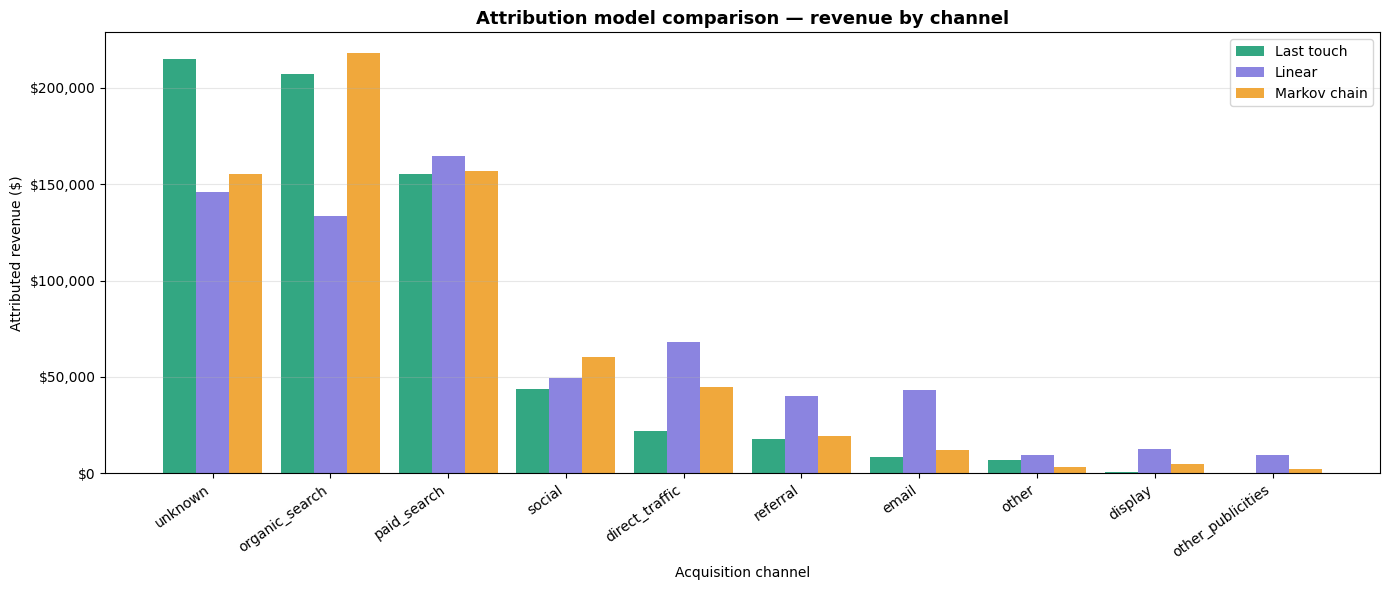

Chart saved


In [7]:
channels = comparison['origin']
x        = np.arange(len(channels))
width    = 0.28

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width,   comparison['last_touch_rev'],              width, label='Last touch',  color='#1D9E75', alpha=0.9)
bars2 = ax.bar(x,           comparison['linear_attributed_revenue'],   width, label='Linear',       color='#7F77DD', alpha=0.9)
bars3 = ax.bar(x + width,   comparison['markov_attributed_revenue'],   width, label='Markov chain', color='#EF9F27', alpha=0.9)

ax.set_xlabel('Acquisition channel')
ax.set_ylabel('Attributed revenue ($)')
ax.set_title('Attribution model comparison — revenue by channel', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=35, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'attribution_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")